In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md


/kaggle/input/datasets/tann22u/placement-dataset/placement.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/tann22u/placement-dataset/placement.csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


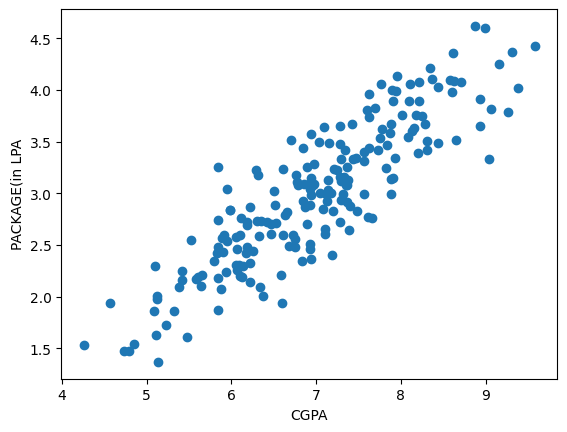

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('PACKAGE(in LPA')
plt.show()

In [4]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [5]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [7]:
lr.fit(X_train, y_train)

LinearRegression()

In [8]:
X_train

,cgpa
79,7.18
197,7.21
38,8.62
24,6.53
122,5.12
...,...
106,6.13
14,7.73
92,7.90
179,7.14


In [9]:
X_test


,cgpa
95,6.63
15,7.25
30,7.36
158,5.95
128,7.93
115,8.35
69,7.30
170,6.22
174,7.32
45,7.87


In [10]:
lr.predict(X_test.iloc[0].values.reshape(1, 1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.78031348])

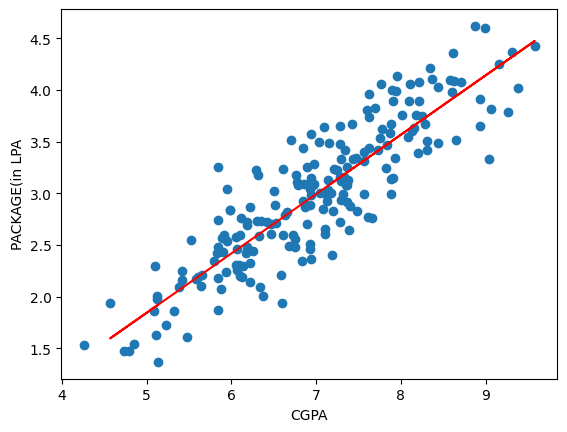

In [11]:
plt.scatter(df['cgpa'], df['package'])
plt.plot(X_train, lr.predict(X_train), color='red')
plt.xlabel('CGPA')
plt.ylabel('PACKAGE(in LPA')
plt.show()

In [12]:
# Slope of line
m = lr.coef_
m

array([0.57425647])

In [13]:
b= lr.intercept_
b

np.float64(-1.0270069374542108)

In [14]:
# Y = mx +b
m * 8.68 + b

array([3.95753925])

# OLS --> Ordinary Least Squares
Its goal is to find the line (or hyperplane) that best fits the data by minimizing the sum of the squared differences between the actual and predicted values.

### Linear Regression Model

+ For one feature: y=β0​+β1​x+ε

+ For multiple features: y=β0​+β1​x1​+β2​x2​+⋯+βn​xn​+ε

Where:
- y = target (dependent variable)
- x = input feature(s)
- β0 = intercept
- β1,β2,… = coefficients
- ε = error term

### OLS Objective Function

OLS minimizes the Residual Sum of Squares (RSS): RSS= i=1∑n​(yi​−y^​i​)2

where:
- yi = actual value
- y^i = predicted value
- n = number of observations

### OLS Solution

The coefficients are computed using the Normal Equation: β^​=(X^T.X)^−1 X^T.y

where:
- X = feature matrix
- y = target vector
- β^ = estimated coefficients

In [ ]:
# Simple Linear Regression
# OLS --> Ordinary Least Squares
class SimpleLR:
    
    def __init__(self):
        self.m = None
        self.b = None
        
    def fit(self,X_train,y_train):
        
        num = 0
        den = 0
        
        for i in range(X_train.shape[0]):
            
            num = num + ((X_train[i] - X_train.mean())*(y_train[i] - y_train.mean()))
            den = den + ((X_train[i] - X_train.mean())*(X_train[i] - X_train.mean()))
        
        self.m = num/den
        self.b = y_train.mean() - (self.m * X_train.mean())
        print(self.m)
        print(self.b)       
    
    def predict(self,X_test):
        
        print(X_test)
        
        return self.m * X_test + self.b